# Demand(t)

Este notebook construye `Demand(t)`, la segunda capa de la arquitectura del sistema: `Demand(t) = Demand_circadian(t) + D_ref · f(StressLoad(t))`, expresada en mg-equivalente/hora para ser comensurable con `Coverage(t)`.

El **bloque 1** construye `Demand_circadian(t)`, el componente circadiano de la demanda, mediante el método Dual Cosines (Chakraborty, Krzyzanski & Jusko, 1999) calibrado sobre el pico y nadir de cortisol reportados por Debono et al. (2009). Se generan dos variantes: una de fase poblacional fija (para los escenarios sintéticos) y otra con la fase desplazada a la hora real de despertar (para el caso n-of-1).

El **bloque 2** calcula `D_ref`, la magnitud de referencia del incremento de demanda inducido por estrés, reanclada a Kirschbaum et al. (1993) vía el incremento de cortisol salival tras el TSST, convertido a mg/h mediante el aclaramiento (CL) de cortisol libre.

El **bloque 3** integra ambos componentes con `f(StressLoad(t))` —el clasificador entrenado en `StressLoad(t).ipynb`, Camino B— mediante una comprobación de sensatez sobre un sujeto real de WESAD (S13), confirmando que el ensamblaje mecánico de las tres piezas funciona correctamente antes de pasar a la validación de la cadena completa (pendiente, en los escenarios sintéticos).

El notebook cierra con una sección de tareas pendientes, documentando qué decisiones de diseño ya están cerradas y cuáles quedan abiertas para las siguientes fases del TFM.

# 0. Imports y configuración de parámetros

Se importan las librerías básicas (`numpy`, `matplotlib`, `pandas`) y se fija el tamaño de figura por defecto para las visualizaciones del notebook.

In [1]:
# Librerías básicas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 5)
tgrid = np.linspace(0, 24, 24*60, endpoint=False)  # rejilla temporal a 1 min de resolución, usada en toda la Sección 1


# 1. Demand_circadian(t) — componente circadiano del modelo de demanda

Construye la primera pieza de `Demand(t) = Demand_circadian(t) + D_ref · f(StressLoad(t))`.

**Historial de esta versión — por qué no es un cosinor simple:**

1. Un cosinor de un armónico anclado a la acrofase real (08:32h, Debono et al. 2009) sitúa el nadir
   modelado en 20:32h, casi 4h desviado del nadir real reportado (00:18h) — limitación estructural
   de cualquier oscilación simétrica de un armónico.
2. Intentar un cosinor de dos armónicos anclado a mesor+pico+nadir reales, o un ajuste por mínimos
   cuadrados con más puntos de anclaje (fase de quiescencia incluida), produjo **valores negativos**
   de concentración en tramos no anclados — inválido para una variable que representa una demanda
   fisiológica. Ver hilo de diseño para el detalle numérico de ambos intentos fallidos.
3. Solución adoptada: **método "Dual Cosines"** (Rohatagi et al. 1996, formalizado en
   Chakraborty, Krzyzanski & Jusko, 1999, *J Pharmacokinet Biopharm* 27(1):23-43, Ecs. 12-14) —
   dos cosenos de periodo distinto (uno para la subida, otro para la bajada) empalmados en los
   tiempos de pico y nadir reales. Acotado por construcción entre Rm-Ramp y Rm+Ramp — nunca negativo.
   Es el método real usado en la literatura de PK/PD para tasas de producción circadiana asimétricas
   (nota: el propio Debono et al. 2009 cita este paper como referencia de método, aunque ellos usan
   cosinor de dos armónicos sobre datos crudos que aquí no tenemos disponibles).

**Decisiones de diseño cerradas:**

- Parámetros del Dual Cosines: Rm=8.75, Ramp=6.75, Tmin=00:18h, Tmax=08:32h — calibrados para que
  el modelo alcance exactamente el pico (15.5 µg/dl-equivalente) y el nadir (2.0) que reporta
  Debono et al. (2009), en los tiempos exactos que reporta.
- **Limitación declarada**: la media temporal de esta curva (8.75) no coincide con el MESOR real
  del cosinor de Debono (5.2, obtenido de datos crudos con ajuste de dos armónicos) — es una
  consecuencia conocida del método Dual Cosines, no un error de cálculo. Se declara explícitamente,
  no se disimula.
- Magnitud diaria total: **producción endógena fisiológica directa, 9.5-9.9 mg/día** (Chan & Debono,
  2010, vía Kerrigan et al. 1993; Esteban & Yergey 1990; Linder et al. 1990) — **no** el rango de
  reemplazo oral clínico (15-25 mg/día, Bornstein et al. 2016), que se descartó como ancla de
  Demand(t) por razón de comensurabilidad: Coverage(t) ya representa la dosis oral administrada
  (Sección 7), y anclar también Demand(t) a dosis oral generaría una resta entre dos magnitudes del
  mismo dominio, ocultando la desalineación estructural que Risk(t) pretende revelar (ver Sección 1
  y Evolucion_del_proyecto_v6.docx, Sección 6, "Comensurabilidad de unidades"). Sin corrección de
  biodisponibilidad (F=1 implícito), por consistencia con Coverage(t) (Sección 7.1).  
- Fase: fija (Tmin/Tmax poblacionales) para escenarios sintéticos; desplazada a la hora media de
  despertar real para el caso n-of-1 (mismo desplazamiento aplicado a Tmin y Tmax, preservando las
  duraciones relativas de subida/bajada).


## 1.1. Pico y nadir reales reportados por Debono et al. (2009)

Estos son los dos puntos de anclaje que definen la forma del ritmo circadiano de cortisol: el valor y la hora del pico (acrofase) y del nadir. Son los valores que cualquier método de modelado debe reproducir, y los que los intentos descartados en 1.2 no consiguen replicar simultáneamente.

In [2]:
pico = 15.5              # µg/dl-equivalente, valor de referencia en el pico (Debono et al. 2009)
T_max = 8 + 32/60        # 08:32h — hora del pico (acrofase)
nadir = 2.0               # µg/dl-equivalente, valor de referencia en el nadir
T_min = 0 + 18/60         # 00:18h — hora del nadir
MESOR_real = 5.2          # µg/dl-equivalente, MESOR real reportado por Debono et al. (2009)

print(f"Pico: {pico} a las {T_max:.3f}h | Nadir: {nadir} a las {T_min:.3f}h | MESOR real: {MESOR_real}")

Pico: 15.5 a las 8.533h | Nadir: 2.0 a las 0.300h | MESOR real: 5.2


## 1.2. Parámetros del Dual Cosines (Chakraborty, Krzyzanski & Jusko, 1999, Ecs. 12-14)

Calibrados para alcanzar exactamente el pico y el nadir que reporta Debono et al. (2009),
en los tiempos exactos que reporta.


In [3]:
# Se trasladan las funciones de demanda circadiana y de cosenos duales a un módulo aparte para poder reutilizarlas 
# en otras partes del proyecto
from formulario_utils import dual_cosines, demand_circadian, RM_DEMAND, RAMP_DEMAND, T_MIN_DEMAND, T_MAX_DEMAND, DAILY_TOTAL_MG_MID, D_REF_MID

In [4]:
# Alias locales: el resto del notebook usa los nombres cortos originales (Rm, Ramp, T_min, T_max,
# pico, nadir). Se recuperan aquí para no tener que reescribir las celdas que ya dependían de ellos.
Rm, Ramp, T_min, T_max = RM_DEMAND, RAMP_DEMAND, T_MIN_DEMAND, T_MAX_DEMAND
pico, nadir = 15.5, 2.0  # valores de referencia de Debono et al. (2009), solo para el print de la comprobación de sensatez

### Comprobación de sensatez: reproduce exactamente pico/nadir, siempre positiva, suave en los empalmes


In [5]:
curva_test = dual_cosines(tgrid, Rm, Ramp, T_min, T_max)

print(f"Min: {curva_test.min():.3f} (objetivo {nadir}) | Max: {curva_test.max():.3f} (objetivo {pico})")
print(f"Siempre positiva: {bool((curva_test > 0).all())}")
print(f"Media temporal (mesor efectivo del modelo): {curva_test.mean():.3f} "
      f"| MESOR real reportado por Debono: 5.2 — discrepancia declarada, ver Sección 0")


Min: 2.000 (objetivo 2.0) | Max: 15.500 (objetivo 15.5)
Siempre positiva: True
Media temporal (mesor efectivo del modelo): 8.750 | MESOR real reportado por Debono: 5.2 — discrepancia declarada, ver Sección 0


## 1.3. Intentos descartados: cosinor de 1 y 2 armónicos

Antes de adoptar el método Dual Cosines, se probaron dos aproximaciones más convencionales en la literatura de ritmos circadianos, ambas descartadas por razones distintas.

### 1.3.1. Cosinor de 1 armonico

Se ajusta un cosinor de un armónico, `y(t) = Rm + Ramp·cos(2π(t-T_max)/24)`, con `Rm` y `Ramp` calculados como punto medio y semiamplitud entre pico y nadir reales.
Un primer intento usa directamente el MESOR real de Debono (5,2) como término constante del cosinor. Al comprobar que esto genera valores negativos, se corrige usando el punto medio entre pico y nadir (`Rm`) en su lugar — resolviendo el problema del signo, aunque no el de la hora del nadir.

Nadir real reportado:   0.30h
Nadir del cosinor 1-armónico: 20.53h
Desviación: 20.23h
¿Algún valor negativo?: True


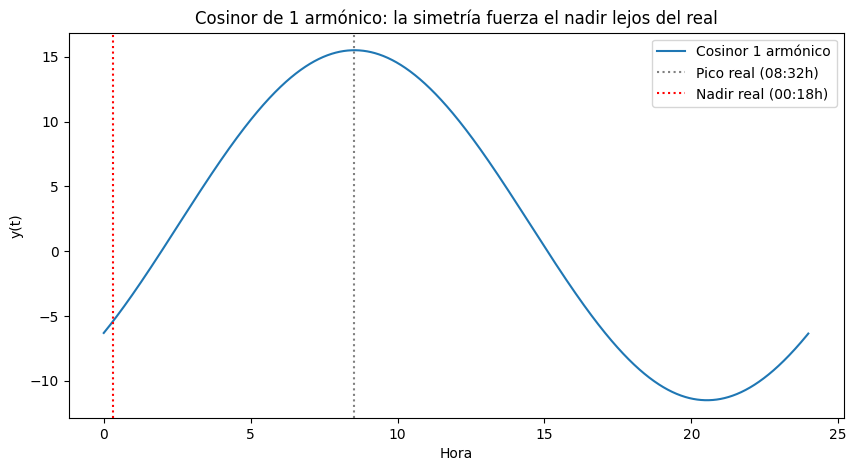

In [6]:
# --- Intento 1: cosinor de 1 armónico, anclado a la acrofase real ---
M = nadir  # placeholder, se sustituye abajo por el mesor correcto de este intento
A = pico - nadir
acrofase = T_max

y_cosinor1 = M + A * np.cos(2*np.pi*(tgrid - acrofase)/24)

print(f"Nadir real reportado:   {T_min:.2f}h")
print(f"Nadir del cosinor 1-armónico: {tgrid[np.argmin(y_cosinor1)]:.2f}h")
print(f"Desviación: {abs(tgrid[np.argmin(y_cosinor1)] - T_min):.2f}h")
print(f"¿Algún valor negativo?: {(y_cosinor1 < 0).any()}")

plt.plot(tgrid, y_cosinor1, label="Cosinor 1 armónico")
plt.axvline(T_max, color="gray", ls=":", label="Pico real (08:32h)")
plt.axvline(T_min, color="red", ls=":", label="Nadir real (00:18h)")
plt.legend(); plt.xlabel("Hora"); plt.ylabel("y(t)")
plt.title("Cosinor de 1 armónico: la simetría fuerza el nadir lejos del real")
plt.show()

**Conclusión:** el cosinor de 1 armónico reproduce correctamente el *valor* del nadir (2,00) pero sitúa su *hora* muy lejos de la real (nadir modelado a las {tgrid[np.argmin(y_cosinor1)]:.2f}h frente a las 00:18h reales) — consecuencia de que un solo armónico fuerza el pico y el nadir a estar siempre a exactamente 12h de distancia, algo que no ocurre en el ritmo circadiano real de cortisol.

### Corrección del mesor (Rm, Ramp) — resuelve el valor, no la hora

Se corrige el intento anterior sustituyendo el MESOR real por `Rm`, el punto medio entre pico y nadir, para eliminar los valores negativos.

Rm=8.75, Ramp=6.75
¿Negativo?: False
Nadir modelado en: 20.53h (real: 0.30h)
Valor del nadir modelado: 2.00 (real: 2.0)


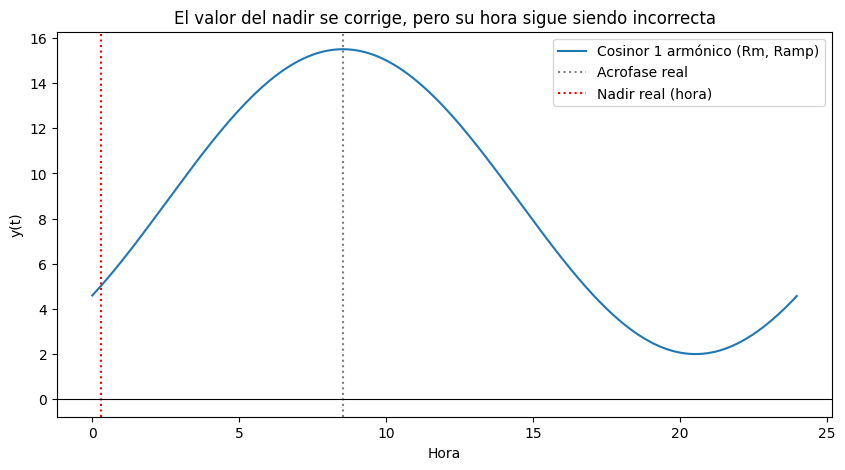

In [7]:
# --- Intento 1.1: mesor calculado como punto medio pico-nadir (Rm, Ramp) ---
Rm_intento = (pico + nadir) / 2
Ramp_intento = (pico - nadir) / 2

y_intento_corregido = Rm_intento + Ramp_intento * np.cos(2*np.pi*(tgrid - T_max)/24)

print(f"Rm={Rm_intento}, Ramp={Ramp_intento}")
print(f"¿Negativo?: {(y_intento_corregido < 0).any()}")
print(f"Nadir modelado en: {tgrid[np.argmin(y_intento_corregido)]:.2f}h (real: {T_min:.2f}h)")
print(f"Valor del nadir modelado: {y_intento_corregido.min():.2f} (real: {nadir})")

plt.plot(tgrid, y_intento_corregido, label="Cosinor 1 armónico (Rm, Ramp)")
plt.axvline(T_max, color="gray", ls=":", label="Acrofase real")
plt.axvline(T_min, color="red", ls=":", label="Nadir real (hora)")
plt.axhline(0, color="black", lw=0.8)
plt.legend(); plt.xlabel("Hora"); plt.ylabel("y(t)")
plt.title("El valor del nadir se corrige, pero su hora sigue siendo incorrecta")
plt.show()

**Conclusión:** el valor del nadir ya es correcto (2,00), pero su hora sigue estando muy alejada de la real (20,53h frente a las 00,30h reales) — consecuencia estructural del cosinor de 1 armónico, que fuerza pico y nadir a estar siempre a 12h de distancia exacta, no del mesor elegido. Esto motiva explorar el cosinor de 2 armónicos en 1.3.2.

### 1.3.2. Cosinor de 2 armónicos 

Se plantea el ajuste como un sistema de ecuaciones no lineales sobre cinco anclajes reales: el valor y la hora del pico, el valor y la hora del nadir (ambos como puntos estacionarios, con derivada nula), y el MESOR real de Debono et al. (2009) como nivel medio del modelo — cinco ecuaciones, cinco incógnitas (mesor, dos amplitudes, dos fases), sin necesitar datos crudos de cortisol.

Solución: A1=7.159, φ1=7.722h, A2=3.387, φ2=8.962h
¿Algún valor negativo?: True | mínimo: -1.914


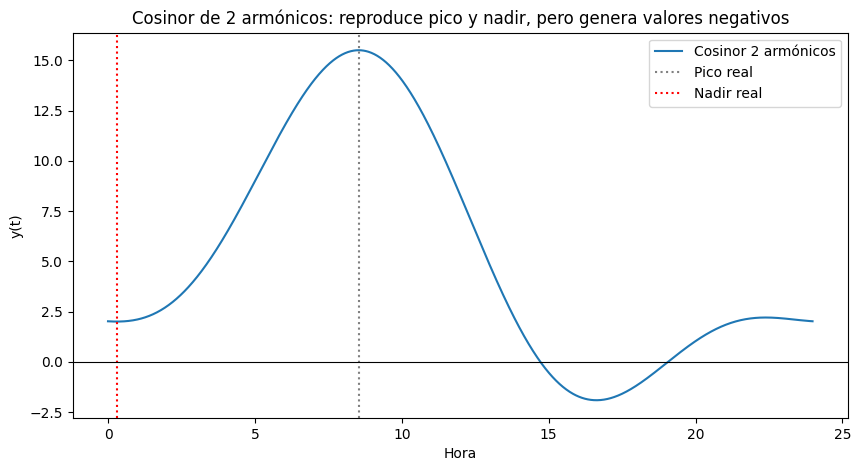

In [8]:
from scipy.optimize import fsolve

w1, w2 = 2*np.pi/24, 2*np.pi/12

def sistema_2_armonicos(params):
    A1, phi1, A2, phi2 = params
    def y(t):
        return MESOR_real + A1*np.cos(w1*(t-phi1)) + A2*np.cos(w2*(t-phi2))
    def dy(t):
        return -A1*w1*np.sin(w1*(t-phi1)) - A2*w2*np.sin(w2*(t-phi2))
    return [y(T_max) - pico, y(T_min) - nadir, dy(T_max), dy(T_min)]

rng = np.random.default_rng(42)
soluciones_canonicas = set()
for _ in range(500):
    x0 = rng.uniform(-10, 10, 4)
    sol, info, ier, msg = fsolve(sistema_2_armonicos, x0, full_output=True)
    if ier == 1 and np.max(np.abs(sistema_2_armonicos(sol))) < 1e-6:
        A1, phi1, A2, phi2 = sol
        if A1 < 0: A1, phi1 = -A1, phi1 + 12
        if A2 < 0: A2, phi2 = -A2, phi2 + 6
        soluciones_canonicas.add((round(A1,3), round(phi1 % 24,3), round(A2,3), round(phi2 % 12,3)))

A1, phi1, A2, phi2 = sorted(soluciones_canonicas)[0]
print(f"Solución: A1={A1}, φ1={phi1}h, A2={A2}, φ2={phi2}h")

y_cosinor2 = MESOR_real + A1*np.cos(w1*(tgrid-phi1)) + A2*np.cos(w2*(tgrid-phi2))
print(f"¿Algún valor negativo?: {(y_cosinor2 < 0).any()} | mínimo: {y_cosinor2.min():.3f}")

plt.plot(tgrid, y_cosinor2, label="Cosinor 2 armónicos")
plt.axvline(T_max, color="gray", ls=":", label="Pico real")
plt.axvline(T_min, color="red", ls=":", label="Nadir real")
plt.axhline(0, color="black", lw=0.8)
plt.legend(); plt.xlabel("Hora"); plt.ylabel("y(t)")
plt.title("Cosinor de 2 armónicos: reproduce pico y nadir, pero genera valores negativos")
plt.show()

**Conclusión:** el cosinor de 2 armónicos sí reproduce correctamente el valor y la hora tanto del pico como del nadir, pero genera un valor negativo (mínimo −1,914) en el tramo no anclado directamente por las restricciones — inválido para una variable que representa una demanda fisiológica.

### 1.3.3. Comparación: cosinor de 1 armónico vs. 2 armónicos vs. Dual Cosines

Se comparan los tres métodos sobre la misma rejilla temporal.

Cosinor 1 armónico  -> ¿negativo?: True  | nadir en 20.53h
Cosinor 2 armónicos -> ¿negativo?: True  | mínimo: -1.91
Dual Cosines        -> ¿negativo?: False  | nadir en 0.30h


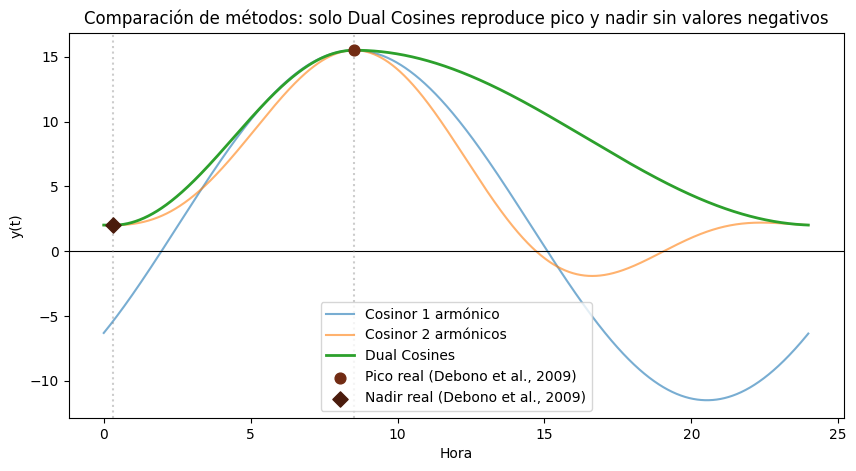

In [9]:
y_dual = dual_cosines(tgrid, Rm, Ramp, T_min, T_max)

print(f"Cosinor 1 armónico  -> ¿negativo?: {(y_cosinor1<0).any()}  | nadir en {tgrid[np.argmin(y_cosinor1)]:.2f}h")
print(f"Cosinor 2 armónicos -> ¿negativo?: {(y_cosinor2<0).any()}  | mínimo: {y_cosinor2.min():.2f}")
print(f"Dual Cosines        -> ¿negativo?: {(y_dual<0).any()}  | nadir en {tgrid[np.argmin(y_dual)]:.2f}h")

plt.plot(tgrid, y_cosinor1, label="Cosinor 1 armónico", alpha=0.6)
plt.plot(tgrid, y_cosinor2, label="Cosinor 2 armónicos", alpha=0.6)
plt.plot(tgrid, y_dual, label="Dual Cosines", linewidth=2)
plt.axhline(0, color="black", lw=0.8)

# --- Pico y nadir reales (Debono et al., 2009) ---
plt.scatter([T_max], [Rm + Ramp], color="#712B13", zorder=5, s=60, label="Pico real (Debono et al., 2009)")
plt.scatter([T_min], [Rm - Ramp], color="#4A1B0C", zorder=5, s=60, marker="D", label="Nadir real (Debono et al., 2009)")
plt.axvline(T_max, color="gray", ls=":", alpha=0.4)
plt.axvline(T_min, color="gray", ls=":", alpha=0.4)

plt.legend(); plt.xlabel("Hora"); plt.ylabel("y(t)")
plt.title("Comparación de métodos: solo Dual Cosines reproduce pico y nadir sin valores negativos")
plt.show()

**Conclusión:** de los tres métodos, solo Dual Cosines reproduce simultáneamente el pico y el nadir reales (valor y hora) sin generar valores negativos — justificando su adopción como método final para `Demand_circadian(t)`.

## 1.4. Verificación del MESOR real por integración

Se cuantifica la discrepancia entre el mesor efectivo del modelo Dual Cosines (media temporal de la curva) y el MESOR real reportado por Debono et al. (2009, 5,2), declarada como limitación en la introducción de la Sección 1.

In [10]:
mesor_real_integrado = np.trapezoid(curva_test, tgrid) / 24

print(f"Rm (punto medio pico-nadir): {Rm}")
print(f"Mesor real (media temporal, por integración): {mesor_real_integrado:.3f}")
print(f"MESOR reportado por Debono (dato publicado):  {MESOR_real}")

area_encima = np.trapezoid(np.clip(curva_test - mesor_real_integrado, 0, None), tgrid)
area_debajo = np.trapezoid(np.clip(mesor_real_integrado - curva_test, 0, None), tgrid)
print(f"\nÁrea por encima del mesor real: {area_encima:.3f}")
print(f"Área por debajo del mesor real: {area_debajo:.3f}  (deberían coincidir)")

Rm (punto medio pico-nadir): 8.75
Mesor real (media temporal, por integración): 8.749
MESOR reportado por Debono (dato publicado):  5.2

Área por encima del mesor real: 51.583
Área por debajo del mesor real: 51.437  (deberían coincidir)


**Conclusión:** el mesor efectivo del modelo Dual Cosines, calculado por integración (8,749), coincide con `Rm` (8,75, punto medio pico-nadir) — la pequeña diferencia de 0,001 es solo redondeo de visualización. Ambos difieren sustancialmente del MESOR real reportado por Debono (5,2), confirmando la discrepancia ya declarada como limitación en la introducción de la Sección 1. Las áreas por encima (51,583) y por debajo (51,437) del mesor calculado coinciden dentro de un margen del 0,3%, atribuible a la resolución de la rejilla temporal (1 min) y al redondeo del mesor usado en el cálculo — consistente con que 8,749 es, en efecto, la media temporal correcta de la curva.

## 1.5. Magnitud diaria total (mg/día)

La Sección 1.1 fija la *forma* del ritmo circadiano a partir del pico y el nadir reales reportados
por Debono et al. (2009) — cuándo sube, cuándo baja, con qué asimetría. Pero esa forma, tal como sale
de `dual_cosines()`, está expresada en las unidades relativas del propio pico/nadir (15,5 y 2,0), no
en mg: su integral en 24h es simplemente `Rm × 24` (el mesor por el número de horas), sin relación
directa con una magnitud fisiológica real.

Esta sección fija esa magnitud real: la cantidad total de hormona producida en 24h, en mg/día.
`demand_circadian()` toma la forma ya calibrada en 1.1 y aplica un único factor de escala global —
`daily_total_mg / integral_de_la_forma_sin_escalar` — de modo que la curva conserva exactamente la
misma forma relativa (mismo pico respecto al nadir, mismas horas), pero su integral en 24h pasa a
coincidir con la magnitud fijada aquí, en mg reales.

In [11]:
# Producción endógena fisiológica directa (Chan & Debono 2010, vía Kerrigan et al. 1993;
# Esteban & Yergey 1990; Linder et al. 1990) — sin corrección de biodisponibilidad,
# por consistencia con Coverage(t) 
daily_total_mg_min = 9.5
daily_total_mg_max = 9.9
daily_total_mg_mid = np.mean([daily_total_mg_min, daily_total_mg_max])

print(f"Magnitud diaria total: {daily_total_mg_min}-{daily_total_mg_max} mg/día "
      f"(punto medio: {daily_total_mg_mid:.2f} mg/día)")

# Nota: el rango completo (no solo el punto medio) se conserva para el futuro análisis de sensibilidad
# Monte Carlo, junto con D_ref y las constantes ka/ke de Coverage(t) 


Magnitud diaria total: 9.5-9.9 mg/día (punto medio: 9.70 mg/día)


**Nota sobre la brecha entre producción fisiológica y pauta oral real:** la magnitud fijada arriba
(9,5-9,9 mg/día) es notablemente menor que la dosis oral real administrada en la pauta de reemplazo
(~20 mg/día, Coverage(t)). Esta brecha no afecta a la validez de Demand_circadian(t) —que se ancla
deliberadamente a producción endógena, no a dosis clínica (ver justificación más arriba en esta misma
sección)— pero merece explicación aparte: ¿por qué la pauta oral necesita administrar el doble de lo
que el cuerpo produce de forma endógena?

No se ha encontrado en la literatura del proyecto una explicación mecanística citable y verificada.
La hipótesis del metabolismo de primer paso hepático se descarta: Derendorf et al. (1991) reporta una
biodisponibilidad oral de hidrocortisona ~96%, incompatible con una pérdida sustancial por primer paso.
La explicación más plausible —no verificada bibliográficamente, pero coherente con el patrón de diente
de sierra observado empíricamente en la comprobación de sensatez (1.9)— es que la dosificación oral
discreta debe compensar los valles entre tomas, a diferencia de la producción endógena continua.

## 1.6. Demand_circadian(t) — versión genérica (fase poblacional fija)

Reescala la forma Dual Cosines (que oscila en unidades relativas de concentración) para que integre
exactamente `daily_total_mg` a lo largo de 24h — separando forma (Dual Cosines, adimensional tras
normalizar) de magnitud (mg/día, de la Sección 1). Usada para escenarios sintéticos.


Se usa la función `demand_circadian()`, que está definida en `formulario_utils.py` (Sección 1.2), como módulo compartido reutilizable por el resto de notebooks del proyecto que necesitan calcular la demanda circadiana.

In [12]:
t = np.linspace(0, 24, 24*60, endpoint=False)
curva_generica_demo = demand_circadian(t, daily_total_mg_mid)
integral_demo = np.trapezoid(curva_generica_demo, t)
print(f"Integral 24h: {integral_demo:.3f} mg (objetivo: {daily_total_mg_mid:.3f} mg)")
print(f"¿Siempre positiva?: {(curva_generica_demo > 0).all()}")

Integral 24h: 9.700 mg (objetivo: 9.700 mg)
¿Siempre positiva?: True


## 1.7. Demand_circadian(t) - Variante personalizada (n-of-1) — Tmin/Tmax desplazados a la hora de despertar real

Mismo Rm/Ramp (forma tomada de literatura), pero Tmin y Tmax desplazados por un único offset —
preserva las duraciones relativas de subida (T_max-T_min) y bajada.

**Hora de despertar real** — calculada a partir de las 20 noches principales identificadas en el
notebook de preprocesamiento (`n_of_1_preprocesamiento.ipynb`, criterio ya cerrado: rem_sleep_min > 0
distingue noche principal de siesta, sin solapamiento). Se usa la **mediana**, no la media: hay un
valor atípico (09:03h el 07/06, ~2h por encima del resto) que desplaza la media a 07:27h pero apenas
mueve la mediana (07:13h tanto con outlier como sin él) — mismo criterio de robustez que ya aplicas
en tu propio preprocesamiento (mediana de duración de sueño, no media).


In [13]:
from formulario_utils import demand_circadian_personalizado

# Hora de despertar real: mediana de las 20 noches principales (rem_sleep_min > 0) del export Xiaomi,
# calculada en n_of_1_preprocesamiento.ipynb (tramo denso, >=21/05/2026, zona horaria ya corregida a
# Europe/Madrid). Mediana elegida sobre la media por robustez frente a un único valor atípico (09:03h
# el 07/06, ~2h por encima del resto; la mediana no se mueve al excluirlo, la media sí: 07:27 -> 07:22).
hora_despertar_mediana = 7 + 13/60  # 07:13h


**Limitación — despertar forzado por alarma, no espontáneo:** la hora de despertar real (mediana
07:13h) proviene de un despertador fijado a una hora externa, no de un despertar espontáneo. El
supuesto Tmax_personal ≈ hora de despertar asume coordinación entre ambos procesos, válida para
despertar espontáneo — con despertador, el pico circadiano real podría ocurrir más tarde de lo que
el modelo asume, desplazando toda la curva de Demand_circadian(t) hacia horas más tempranas de lo
real. Podría estar relacionado con el hallazgo abierto de la Sección 6.2 (adelanto sistemático de
2-4h del mínimo circadiano de HR respecto al punto medio del sueño) — no confirmado, declarado como
hipótesis a explorar conjuntamente.

## 1.8. Visualización y comprobación final de sensatez


In [14]:
t = np.linspace(0, 24, 24*60, endpoint=False)

curva_generica = demand_circadian(t, daily_total_mg_mid)
curva_personalizada = demand_circadian_personalizado(t, daily_total_mg_mid, hora_despertar_mediana)

integral_generica = np.trapezoid(curva_generica, t)
integral_personalizada = np.trapezoid(curva_personalizada, t)
print(f"Integral 24h (genérica):      {integral_generica:.3f} mg  (objetivo: {daily_total_mg_mid:.3f} mg)")
print(f"Integral 24h (personalizada): {integral_personalizada:.3f} mg  (objetivo: {daily_total_mg_mid:.3f} mg)")
print(f"Ambas siempre positivas: {bool((curva_generica > 0).all()) and bool((curva_personalizada > 0).all())}")


Integral 24h (genérica):      9.700 mg  (objetivo: 9.700 mg)
Integral 24h (personalizada): 9.700 mg  (objetivo: 9.700 mg)
Ambas siempre positivas: True


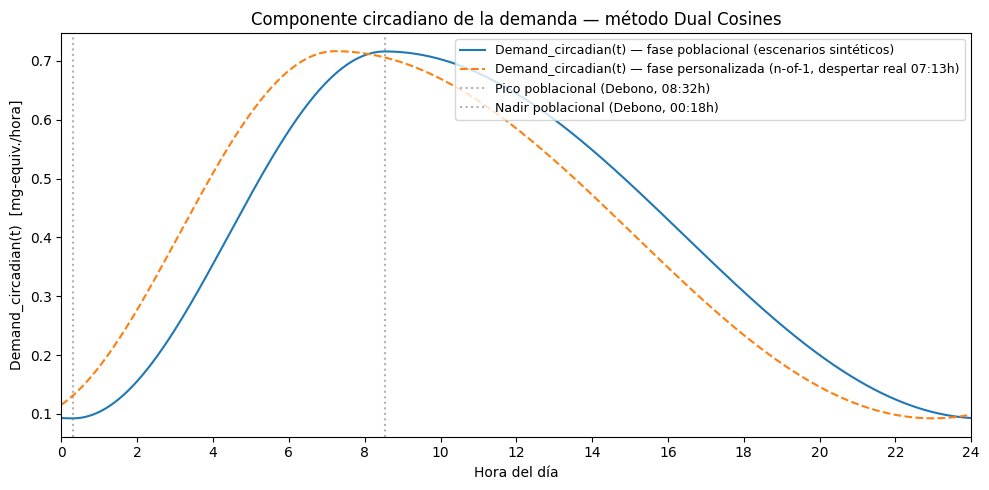

In [15]:
fig, ax = plt.subplots()

ax.plot(t, curva_generica, label="Demand_circadian(t) — fase poblacional (escenarios sintéticos)")
ax.plot(t, curva_personalizada, label="Demand_circadian(t) — fase personalizada (n-of-1, despertar real 07:13h)",
        linestyle="--")

ax.axvline(T_max, color="gray", linestyle=":", alpha=0.6, label="Pico poblacional (Debono, 08:32h)")
ax.axvline(T_min, color="gray", linestyle=":", alpha=0.6, label="Nadir poblacional (Debono, 00:18h)")

ax.set_xlabel("Hora del día")
ax.set_ylabel("Demand_circadian(t)  [mg-equiv./hora]")
ax.set_xticks(range(0, 25, 2))
ax.set_xlim(0, 24)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Componente circadiano de la demanda — método Dual Cosines")
plt.tight_layout()
plt.show()


## 1.9. Comprobación de sensatez — Demand_circadian(t) vs. Coverage(t)

Simulación de un día basal sin estrés (f(StressLoad)=0), comparando Demand_circadian(t) con
Coverage(t) bajo la pauta real (10-5-5mg), usando el modelo de Bateman completo con las constantes
cinéticas de Derendorf et al. (1991): ka≈1,3874 h⁻¹, ke≈0,4077 h⁻¹ (t½≈1,7h, tmax≈1,25h).

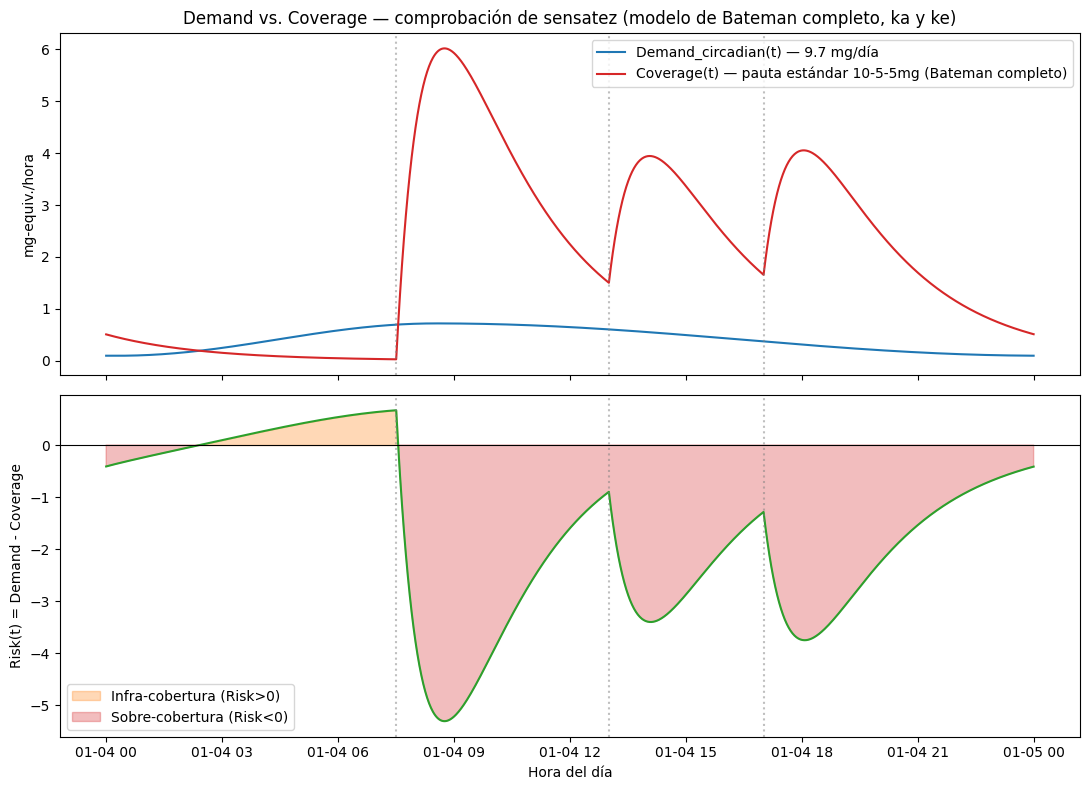

Risk(t) > 0 (infra-cobertura) durante 21.5% del día
Risk(t) mínimo (máxima sobre-cobertura): -5.31 mg/h, a las 08:45
Risk(t) máximo (máxima infra-cobertura): 0.67 mg/h, a las 07:30


In [16]:
# --- Comprobación de sensatez corregida: usa el modelo de Bateman completo (con ke), no el
# coverage_rate() antiguo que omitía la eliminación sistémica (bug detectado 11/08/2026) ---
from formulario_utils import PKParams, build_standard_schedule, compute_coverage

pk = PKParams()  # ka≈1.3874 h⁻¹, ke≈0.4077 h⁻¹ (Derendorf et al., 1991)

# Generamos varios días para descartar el transitorio del primer día (igual que en el notebook
# de escenarios sintéticos, Sección 6.1)
inicio_demo = pd.Timestamp("2026-01-01")
schedule_demo = build_standard_schedule(inicio_demo, n_days=5)  # horario por defecto: 07:30/12:00/17:00, 10-5-5mg

rejilla_demo = pd.date_range(inicio_demo, inicio_demo + pd.Timedelta(days=5), freq="1min")
coverage_full = compute_coverage(schedule_demo, rejilla_demo, pk)

# Nos quedamos con un día ya en estado estacionario (día 4, para tener margen de sobra)
dia_ref_inicio = inicio_demo + pd.Timedelta(days=3)
dia_ref_fin = inicio_demo + pd.Timedelta(days=4)
coverage = coverage_full[(coverage_full.index >= dia_ref_inicio) & (coverage_full.index < dia_ref_fin)]

horas_del_dia = (coverage.index - coverage.index.normalize()) / pd.Timedelta(hours=1)
demand = pd.Series(demand_circadian(horas_del_dia.values, daily_total_mg=daily_total_mg_mid), index=coverage.index)

risk = demand - coverage

horas_dosis_demo = [7.5, 13.0, 17.0]  # horario por defecto de build_standard_schedule, para las líneas verticales

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(coverage.index, demand.values, label=f"Demand_circadian(t) — {daily_total_mg_mid:.1f} mg/día", color="C0")
axes[0].plot(coverage.index, coverage.values, label="Coverage(t) — pauta estándar 10-5-5mg (Bateman completo)", color="C3")
for h in horas_dosis_demo:
    axes[0].axvline(dia_ref_inicio + pd.Timedelta(hours=h), color="gray", ls=":", alpha=0.5)
axes[0].set_ylabel("mg-equiv./hora")
axes[0].legend()
axes[0].set_title("Demand vs. Coverage — comprobación de sensatez (modelo de Bateman completo, ka y ke)")

axes[1].plot(coverage.index, risk.values, color="C2")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].fill_between(coverage.index, risk.values, 0, where=(risk.values > 0), color="C1", alpha=0.3, label="Infra-cobertura (Risk>0)")
axes[1].fill_between(coverage.index, risk.values, 0, where=(risk.values < 0), color="C3", alpha=0.3, label="Sobre-cobertura (Risk<0)")
for h in horas_dosis_demo:
    axes[1].axvline(dia_ref_inicio + pd.Timedelta(hours=h), color="gray", ls=":", alpha=0.5)
axes[1].set_ylabel("Risk(t) = Demand - Coverage")
axes[1].set_xlabel("Hora del día")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Risk(t) > 0 (infra-cobertura) durante {100*(risk.values > 0).mean():.1f}% del día")
print(f"Risk(t) mínimo (máxima sobre-cobertura): {risk.min():.2f} mg/h, a las {risk.idxmin().strftime('%H:%M')}")
print(f"Risk(t) máximo (máxima infra-cobertura): {risk.max():.2f} mg/h, a las {risk.idxmax().strftime('%H:%M')}")

**Conclusión:** con la pauta estándar 10-5-5mg y sin componente de estrés (f(StressLoad)=0), Risk(t)
es positivo (infra-cobertura) durante el 21,5% del día, con un máximo de 0,67 mg/h a las 07:30 —justo
antes de la primera toma, cuando la cobertura de la noche anterior ya se ha disipado y la demanda
circadiana empieza a subir hacia su pico matutino. La sobre-cobertura es más pronunciada (mínimo
−5,31 mg/h a las 08:45, poco después de la toma matutina de 10mg) que la infra-cobertura, reflejando
que la pauta oral prioriza evitar déficits sobre minimizar excesos. El patrón de diente de sierra
esperado (picos de sobre-cobertura tras cada toma, deriva hacia infra-cobertura entre tomas) se
confirma visualmente en el gráfico superior.

La curva de Demand_circadian(t) en este gráfico es la misma curva Dual Cosines ya validada en la
Sección 1 (mismo pico, mismo nadir, mismas horas) — su oscilación aparece visualmente aplanada aquí
únicamente porque comparte eje con Coverage(t), cuyas oscilaciones tras cada toma (de 0 a varios mg/h
en cuestión de minutos) son de una magnitud mucho mayor que la variación suave de Demand a lo largo
del día.

# 2. Cálculo de D_ref

### D_ref — reanclaje a Kirschbaum et al. (1993), vía TSST

Se descarta Allolio (2015) como ancla de D_ref: describe un estrés de severidad "mayor", distinta
de la que StressLoad(t) es capaz de reconocer —el clasificador se entrena exclusivamente sobre el
protocolo TSST del dataset WESAD (Schmidt et al., 2018)—, por lo que anclar D_ref a una referencia
de mayor severidad generaría una desconexión entre lo que D_ref pretende representar y lo que
StressLoad(t) puede detectar. Además, Allolio reporta una recomendación de dosis clínica, no una
estimación de producción fisiológica, y el sistema no formula recomendaciones de pauta de medicación.

El ancla vigente es Kirschbaum, Pirke & Hellhammer (1993): el incremento absoluto de cortisol
salival tras un TSST, 5,3-8,2 nmol/l —el mismo tipo de estresor que WESAD—. La conversión a mg/h se
realiza mediante el aclaramiento (CL) de cortisol libre, asumiendo estado estacionario:
Tasa = ΔConcentración × CL, con dos fuentes independientes de CL: Simon et al. (2010) y Werumeus
Buning et al. (2017).

**Limitación de alcance:** el sistema no puede detectar ni representar un estrés más severo que el
TSST, dado que StressLoad(t) satura en la firma fisiológica de ese único tipo de estresor presente
en WESAD (desarrollado en Evolucion_del_proyecto).

In [17]:
# --- D_ref vía Kirschbaum et al. (1993) + CL de cortisol libre ---

# Incremento absoluto de cortisol salival tras TSST (Kirschbaum, Pirke & Hellhammer, 1993)
delta_c_nmol_L = {"min": 5.3, "max": 8.2}

# Aclaramiento (CL) de cortisol libre, dos fuentes independientes ya verificadas
CL_L_h = {
    "Simon et al. 2010": 235.78,
    "Werumeus Buning et al. 2017": (226 + 227) / 2,  # punto medio del rango reportado
}

MOLAR_MASS_CORTISOL = 362.46  # g/mol
NMOL_TO_MG = MOLAR_MASS_CORTISOL / 1e9 * 1000  # = 0.00036246 mg/nmol

resultados = {}
for fuente, cl in CL_L_h.items():
    tasa_min = delta_c_nmol_L["min"] * cl * NMOL_TO_MG
    tasa_max = delta_c_nmol_L["max"] * cl * NMOL_TO_MG
    resultados[fuente] = (round(tasa_min, 3), round(tasa_max, 3))
    print(f"{fuente}: CL={cl:.2f} L/h -> D_ref = {tasa_min:.3f} - {tasa_max:.3f} mg/h")

d_ref_min = min(v[0] for v in resultados.values())
d_ref_max = max(v[1] for v in resultados.values())
d_ref_mid = (d_ref_min + d_ref_max) / 2

print(f"\nD_ref (rango combinado, ambas fuentes de CL): {d_ref_min:.2f} - {d_ref_max:.2f} mg/h")
print(f"D_ref punto medio: {d_ref_mid:.2f} mg/h")

Simon et al. 2010: CL=235.78 L/h -> D_ref = 0.453 - 0.701 mg/h
Werumeus Buning et al. 2017: CL=226.50 L/h -> D_ref = 0.435 - 0.673 mg/h

D_ref (rango combinado, ambas fuentes de CL): 0.43 - 0.70 mg/h
D_ref punto medio: 0.57 mg/h


**Conclusión:** las dos fuentes independientes de aclaramiento convergen en el mismo orden de
magnitud (Simon et al. 2010: 0,453-0,701 mg/h; Werumeus Buning et al. 2017: 0,435-0,673 mg/h),
reforzando la fiabilidad de la estimación pese a partir de una única cifra de incremento de cortisol
(Kirschbaum et al. 1993). El rango combinado resultante es 0,43-0,70 mg/h, con un punto medio de
0,57 mg/h — el valor de `D_ref` usado en la integración final de `Demand(t)` (Sección 3).

# 3. Demand(t) — integración completa: Demand_circadian(t) + D_ref·f(StressLoad(t))

Ensambla el modelo de demanda completo, combinando:
- Demand_circadian(t) y D_ref (Secciones 1-2 de este notebook).
- El clasificador de StressLoad(t) (`StressLoad(t).ipynb`, Camino B).

**Comprobación de sensatez, no validación:** se usa un fragmento de WESAD (sujeto S13, el de mejor
rendimiento en Camino B) para comprobar que el ensamblaje mecánico funciona — el modelo se entrenó
con `fit()` sobre el 100% de `df_loso`, incluido S13, así que esto es una prueba in-sample, no
evidencia de rendimiento. La validación real de la cadena completa es la matriz de escenarios
sintéticos, pendiente, con los 4 sujetos reservados (S5, S6, S10, S11).

## 3.1. StressLoad(t) — carga del clasificador entrenado (Camino B)

Se cargan el dataset `df_loso`, la lista de columnas de Camino B y el modelo de Random Forest ya
entrenado en `StressLoad(t).ipynb`.

In [18]:
import json
import joblib

with open("WESAD_config_rutas.json") as f:
    config_rutas = json.load(f)

rutas_art = config_rutas["rutas_artefactos_stressload"]

df_loso = pd.read_parquet(rutas_art["df_loso"], engine="fastparquet")
with open(rutas_art["columnas_camino_B"]) as f:
    columnas_camino_B = json.load(f)
modelo_stress = joblib.load(rutas_art["modelo_final"])

print(f"df_loso cargado: {df_loso.shape[0]} filas, {df_loso['ID_sujeto'].nunique()} sujetos")
print(f"columnas_camino_B: {columnas_camino_B}")

df_loso cargado: 398 filas, 11 sujetos
columnas_camino_B: ['HR_mean_norm', 'HR_mean_roll_mean_5m_norm', 'HR_mean_roll_std_5m_norm', 'HR_mean_roll_mean_10m_norm', 'HR_mean_roll_std_10m_norm', 'HR_mean_norm_lag_1m_norm', 'HR_mean_norm_lag_2m_norm']


El dataset `df_loso` (398 filas, 11 sujetos), la lista de columnas de Camino B y el modelo de Random
Forest entrenado quedan cargados y listos para aplicar sobre el fragmento de prueba de S13.

## 3.2. Extraer el sujeto 13 para prueba de sensatez y aplicar el clasificador

In [19]:
# --- Fragmento de S13 (mejor rendimiento en Camino B, ver desglose en StressLoad(t).ipynb) ---
s13 = df_loso[df_loso["ID_sujeto"] == "S13"].sort_values("minuto_id").reset_index(drop=True)

X_s13 = s13[columnas_camino_B]
stress_pred = modelo_stress.predict(X_s13)  # etiqueta binaria 0/1, umbral por defecto del RF

s13["stress_pred"] = stress_pred

print(f"Minutos totales S13: {len(s13)}")
print(f"Minutos predichos como estrés: {stress_pred.sum()} ({100*stress_pred.mean():.1f}%)")
print(f"Minutos reales de estrés (target): {s13['target'].sum()} ({100*s13['target'].mean():.1f}%)")
print(f"Coincidencia predicción-real: {(s13['stress_pred']==s13['target']).mean()*100:.1f}%")

Minutos totales S13: 37
Minutos predichos como estrés: 11 (29.7%)
Minutos reales de estrés (target): 11 (29.7%)
Coincidencia predicción-real: 100.0%


Sobre los 37 minutos disponibles de S13, el clasificador predice exactamente 11 minutos de estrés
(29,7%), coincidiendo al 100% con la etiqueta real de estado. Al tratarse de una prueba in-sample
(S13 formó parte del conjunto de entrenamiento), esta coincidencia perfecta no debe interpretarse
como evidencia de rendimiento del clasificador —eso ya se reportó mediante LOSO en `StressLoad(t).ipynb`—,
sino únicamente como confirmación de que el ensamblaje mecánico (carga del modelo, predicción sobre
un fragmento real) funciona correctamente.

## 3.3. Calcular f(StressLoad(t)) — duty cycle sobre ventana de 25 minutos

`f(StressLoad(t))` convierte la etiqueta binaria de StressLoad(t) (0/1, minuto a minuto) en una
señal continua que puede sumarse a Demand_circadian(t) sin introducir escalones bruscos. Usar la
etiqueta binaria directamente haría que Demand(t) saltara de golpe un valor entero de D_ref mg/h
cada vez que el clasificador cambiara de predicción entre minutos consecutivos —un comportamiento
no realista fisiológicamente (la respuesta de estrés no es un interruptor binario) y muy sensible a
un único minuto mal clasificado.

`f(·)` se define como un *duty cycle*: la fracción de minutos clasificados como estrés dentro de una
ventana móvil retrospectiva. Un valor de 0,58, por ejemplo, no representa una probabilidad de estrés
ni una medida de confianza del clasificador — es la frecuencia observada de minutos "estrés" entre
los recientes.

**Tamaño de ventana: 25 minutos.** Se fija a partir de la latencia fisiológica del eje HPA reportada
por Gunnar & Quevedo (2007): el cortisol alcanza su pico aproximadamente 25 minutos después del
inicio de un estresor agudo. La ventana de promediado de `f(StressLoad(t))` se alinea así con esta
latencia real, en lugar de con un criterio arbitrario de suavizado de señal.


In [20]:
# --- f(StressLoad(t)): duty cycle sobre ventana de 25 min ---
# Ventana alineada con la latencia fisiológica del eje HPA (Gunnar & Quevedo, 2007):
# el cortisol alcanza su pico ~25 min tras el inicio de un estresor agudo.
VENTANA_DUTY_CYCLE_MIN = 25

s13["f_stressload"] = (
    s13["stress_pred"]
    .rolling(window=VENTANA_DUTY_CYCLE_MIN, min_periods=1)
    .mean()
)

print(f"f(StressLoad(t)) — rango: {s13['f_stressload'].min():.3f} a {s13['f_stressload'].max():.3f}")

f(StressLoad(t)) — rango: 0.000 a 0.440


**Conclusión:** sobre los 37 minutos de S13, `f(StressLoad(t))` oscila entre 0,000 y 0,440 —nunca
alcanza 1,0, porque la ventana de 25 minutos es más larga que cualquier episodio continuo de estrés
predicho en este fragmento, diluyendo el duty cycle incluso en los tramos de mayor actividad.

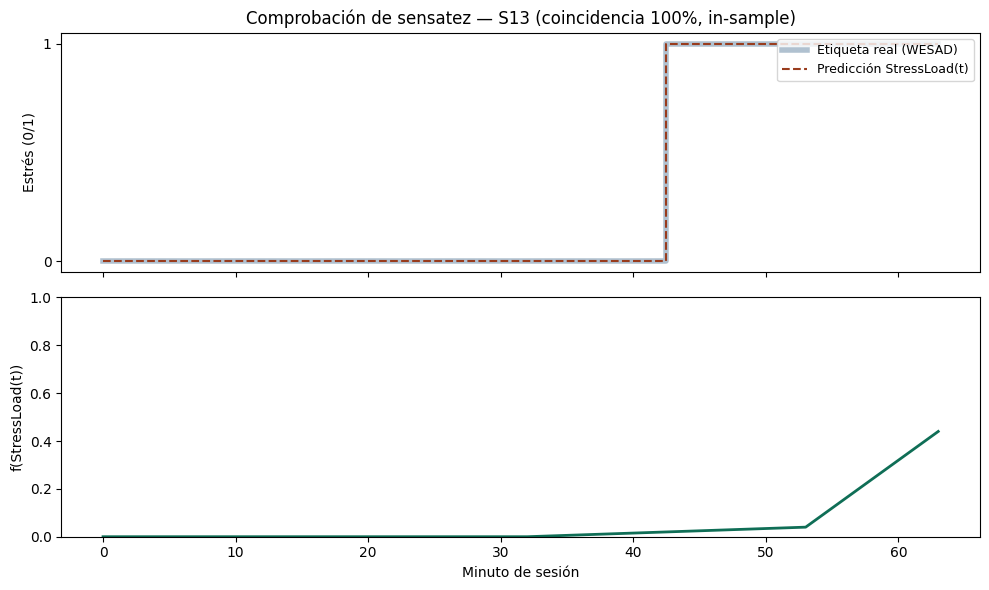

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].step(s13["minuto_id"], s13["target"], where='mid', label="Etiqueta real (WESAD)",
             color="#1F4E79", linewidth=4, alpha=0.35)
axes[0].step(s13["minuto_id"], s13["stress_pred"], where='mid', label="Predicción StressLoad(t)",
             color="#993C1D", linewidth=1.5, linestyle='--')
axes[0].set_ylabel("Estrés (0/1)")
axes[0].set_yticks([0, 1])
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_title("Comprobación de sensatez — S13 (coincidencia 100%, in-sample)")

axes[1].plot(s13["minuto_id"], s13["f_stressload"], color="#0F6E56", linewidth=2)
axes[1].set_ylabel("f(StressLoad(t))")
axes[1].set_xlabel("Minuto de sesión")
axes[1].set_ylim(0, 1)

plt.tight_layout()
#plt.savefig('comprobacion_sensatez_s13.png', dpi=200, bbox_inches='tight')
plt.show()

## 3.4. Ensamblaje final: Demand(t) sobre el fragmento de S13

Se combinan los tres componentes ya calculados —Demand_circadian(t), D_ref y f(StressLoad(t))— en
`Demand(t)` completo, ancladas temporalmente a una sesión arbitraria (inicio a mediodía, solo a
efectos de esta comprobación de sensatez), y se visualiza junto a la señal de estrés que lo genera.

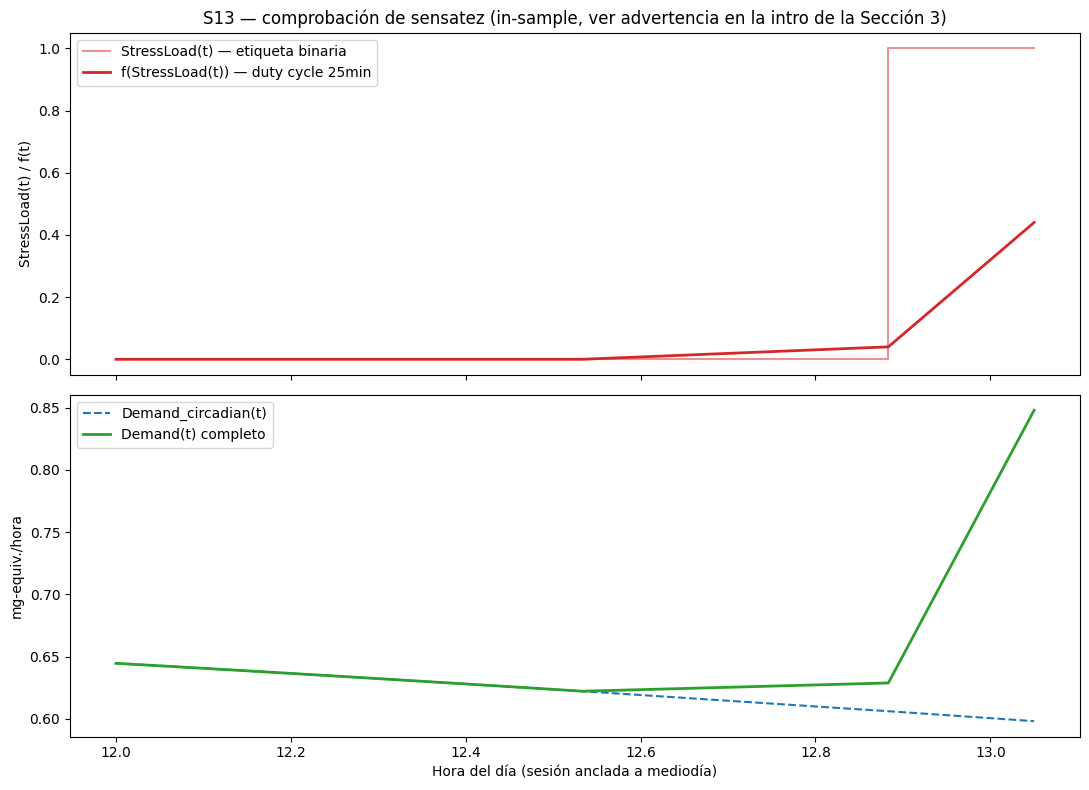

Demand_circadian(t) en la sesión: 0.598 - 0.645 mg/h
Demand(t) completo: 0.622 - 0.848 mg/h
Incremento máximo atribuible al estrés: 0.250 mg/h


In [22]:
# --- Anclaje temporal de la sesión (arbitrario, solo para esta comprobación de sensatez) ---
HORA_INICIO_SESION = 12.0  # mediodía 

s13["hora_dia"] = HORA_INICIO_SESION + s13["minuto_id"] / 60.0

# --- D_ref vigente (Kirschbaum et al. 1993, ver Sección 2) ---
D_REF_MID = d_ref_mid  # 0.57 mg/h, ya calculado en la sección 2

# --- Demand_circadian(t) sobre las horas de la sesión ---
s13["demand_circadian"] = demand_circadian(s13["hora_dia"].values, daily_total_mg=daily_total_mg_mid)

# --- Demand(t) completo ---
s13["demand_total"] = s13["demand_circadian"] + D_REF_MID * s13["f_stressload"]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(s13["hora_dia"], s13["stress_pred"], drawstyle="steps-post", color="C3", alpha=0.5, label="StressLoad(t) — etiqueta binaria")
axes[0].plot(s13["hora_dia"], s13["f_stressload"], color="C3", linewidth=2, label=f"f(StressLoad(t)) — duty cycle {VENTANA_DUTY_CYCLE_MIN}min")
axes[0].set_ylabel("StressLoad(t) / f(t)")
axes[0].legend()
axes[0].set_title(f"S13 — comprobación de sensatez (in-sample, ver advertencia en la intro de la Sección 3)")

axes[1].plot(s13["hora_dia"], s13["demand_circadian"], color="C0", linestyle="--", label="Demand_circadian(t)")
axes[1].plot(s13["hora_dia"], s13["demand_total"], color="C2", linewidth=2, label="Demand(t) completo")
axes[1].set_ylabel("mg-equiv./hora")
axes[1].set_xlabel("Hora del día (sesión anclada a mediodía)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Demand_circadian(t) en la sesión: {s13['demand_circadian'].min():.3f} - {s13['demand_circadian'].max():.3f} mg/h")
print(f"Demand(t) completo: {s13['demand_total'].min():.3f} - {s13['demand_total'].max():.3f} mg/h")
print(f"Incremento máximo atribuible al estrés: {(s13['demand_total'] - s13['demand_circadian']).max():.3f} mg/h")

**Conclusión:** el ensamblaje mecánico completo de `Demand(t)` funciona correctamente sobre el
fragmento de S13. `stress_pred` (etiqueta binaria) salta de 0 a 1 de forma abrupta en cuanto el
clasificador detecta el inicio del TSST, mientras que `f_stressload` —al ser una media retrospectiva
sobre una ventana de 25 minutos— asciende de forma gradual, sin alcanzar 1,0 dentro de los 37 minutos
de la sesión: su máximo observado (0,440) refleja que la ventana necesita acumular una proporción
sostenida de minutos "estrés" para acercarse a 1, algo que un episodio de solo 37 minutos no llega a
completar. Con un episodio de estrés más largo (más habitual en un contexto real que en un protocolo
de laboratorio de 37 minutos), `f(t)` seguiría ascendiendo por encima de 0,44.

Esta suavización tiene una implicación que conviene declarar: `f(t)` no captura el instante exacto en
que empieza o termina el estrés real, sino una versión desplazada en el tiempo del evento —asciende
con retraso al inicio y desciende con retraso al final, arrastrando minutos "1" de la ventana después
de que el estrés real haya cesado. Es un comportamiento intencionado (atenúa artefactos puntuales del
sensor), pero relevante si se compara el timing exacto de `Risk(t)` contra el registro EMA en la
validación n-of-1.

La aritmética del ensamblaje es consistente: con `f≈0,44` en el pico y `D_ref≈0,57` mg/h, el
incremento esperado es `0,57 × 0,44 ≈ 0,25` mg/h, coincidiendo con el resultado reportado por el
código — sin errores de signo ni de escala en la integración de los tres componentes. Este resultado
también confirma, con un caso real y no solo con el cálculo abstracto, que anclar `D_ref` a Kirschbaum
et al. (1993) produce un pulso de estrés que casi duplica la demanda basal (0,6 → 0,85 mg/h) sin
dominarla por completo —a diferencia de lo que habría ocurrido con Allolio como ancla (≈13,3 mg/h),
que habría enmascarado por completo la variación circadiana de fondo—.

Con esto, `Demand(t) = Demand_circadian(t) + D_ref·f(StressLoad(t))` queda completo y ensamblado,
superando su comprobación de sensatez de componente individual —coherente con el criterio de validar
cada capa por separado antes de la cadena completa, ya aplicado a StressLoad(t) y Coverage(t)—. La
validación de la cadena completa (escenarios sintéticos, validación n-of-1) queda pendiente y es
independiente de este cierre.

# 4. Limitaciones y trabajo futuro

- **Puntos medios vs. rango completo (decisión cerrada):** todos los cálculos de este notebook usan
  el punto medio de cada rango (`daily_total_mg_mid = 9,70 mg/día`; `d_ref_mid = 0,57 mg/h`). Los
  rangos completos (9,5-9,9 mg/día; 0,43-0,70 mg/h) quedan documentados pero no se propagan mediante
  análisis de sensibilidad Monte Carlo en este TFM — junto con la incertidumbre de `ka/ke` de
  Coverage(t), este análisis se declara como trabajo futuro, fuera del alcance de la presente versión.